In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


import warnings
warnings.filterwarnings('ignore')

Read the data set

In [3]:
music = pd.read_csv('tracks_features.csv')

In [4]:
music.head()

,id,name,album,album_id,artists,artist_ids,track_number,disc_number,explicit,danceability,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,release_date
0,7lmeHLHBe4nmXzuXc0HDjk,Testify,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],1,1,False,0.470,...,0.0727,0.02610,0.000011,0.3560,0.503,117.906,210133,4.0,1999,1999-11-02
1,1wsRitfRRtWyEapl0q22o8,Guerrilla Radio,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],2,1,True,0.599,...,0.1880,0.01290,0.000071,0.1550,0.489,103.680,206200,4.0,1999,1999-11-02
2,1hR0fIFK2qRG3f3RF70pb7,Calm Like a Bomb,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],3,1,False,0.315,...,0.4830,0.02340,0.000002,0.1220,0.370,149.749,298893,4.0,1999,1999-11-02
3,2lbASgTSoDO7MTuLAXlTW0,Mic Check,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],4,1,True,0.440,...,0.2370,0.16300,0.000004,0.1210,0.574,96.752,213640,4.0,1999,1999-11-02
4,1MQTmpYOZ6fcMQc56Hdo7T,Sleep Now In the Fire,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],5,1,False,0.426,...,0.0701,0.00162,0.105000,0.0789,0.539,127.059,205600,4.0,1999,1999-11-02


Data Cleaning

In [5]:
music.shape

(1204025, 24)

In [6]:
music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1204025 entries, 0 to 1204024
Data columns (total 24 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1204025 non-null  object 
 1   name              1204022 non-null  object 
 2   album             1204014 non-null  object 
 3   album_id          1204025 non-null  object 
 4   artists           1204025 non-null  object 
 5   artist_ids        1204025 non-null  object 
 6   track_number      1204025 non-null  int64  
 7   disc_number       1204025 non-null  int64  
 8   explicit          1204025 non-null  bool   
 9   danceability      1204025 non-null  float64
 10  energy            1204025 non-null  float64
 11  key               1204025 non-null  int64  
 12  loudness          1204025 non-null  float64
 13  mode              1204025 non-null  int64  
 14  speechiness       1204025 non-null  float64
 15  acousticness      1204025 non-null  float64
 16  

In [7]:
music.isnull().sum()

id                   0
name                 3
album               11
album_id             0
artists              0
artist_ids           0
track_number         0
disc_number          0
explicit             0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
duration_ms          0
time_signature       0
year                 0
release_date         0
dtype: int64

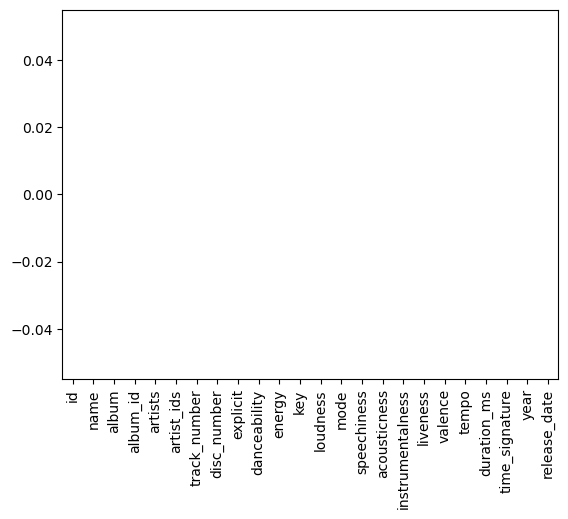

In [8]:
music.dropna(inplace= True)
music.isnull().sum().plot.bar()
plt.show()

In [9]:
music.isnull().sum()

id                  0
name                0
album               0
album_id            0
artists             0
artist_ids          0
track_number        0
disc_number         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
year                0
release_date        0
dtype: int64

Remove unnecessary columns

In [10]:
music = music .drop(['id','album_id','disc_number','track_number','artist_ids'],axis =1)

In [32]:
music.isnull().sum()

name                0
album               0
artists             0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
year                0
release_date        0
dtype: int64

EDA

In [11]:
# Feature selection
features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'loudness', 'valence']
music_features = music[features]

# Preprocessing: Normalize the features
scaler = StandardScaler()
music_features_scaled = scaler.fit_transform(music_features)

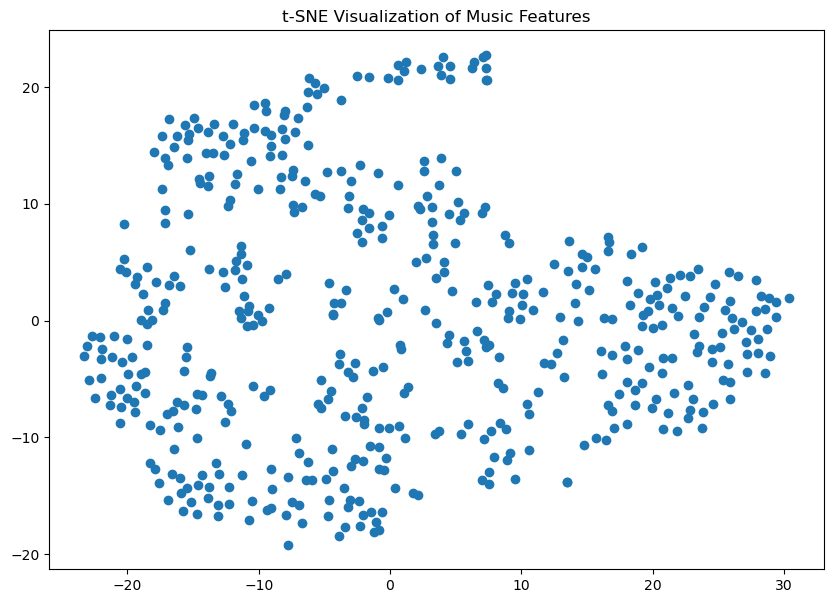

In [12]:
# Take a sample of the dataset for t-SNE visualization
sample_size = 500  # Adjust the sample size as needed
music_sample = music_features_scaled[:sample_size]

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=0)
tsne_data = tsne.fit_transform(music_sample)

# Plot the t-SNE results
plt.figure(figsize=(10, 7))
plt.scatter(tsne_data[:, 0], tsne_data[:, 1])
plt.title('t-SNE Visualization of Music Features')

plt.show()

In [13]:
music['name'].nunique(), music.shape

(850939, (1204012, 19))

In [14]:
music = music.sort_values(by=['key'], ascending=False)
music.drop_duplicates(subset=['name'], keep='first', inplace=True)

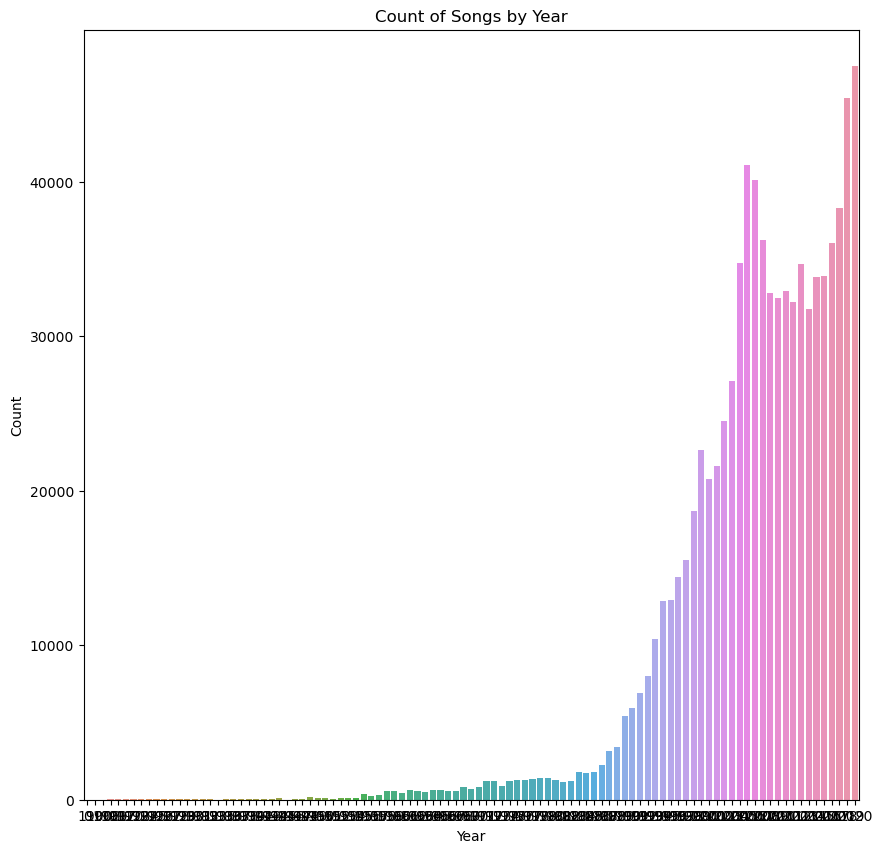

In [15]:

if 'year' in music.columns:
    plt.figure(figsize=(10, 10))
    sns.countplot(x='year', data=music)
    plt.title('Count of Songs by Year')
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.show()
else:
    print("The 'year' column does not exist in the dataframe.")

In [16]:
floats = []
for col in music.columns:
  if music[col].dtype == 'float':
    floats.append(col)
 
len(floats)

10

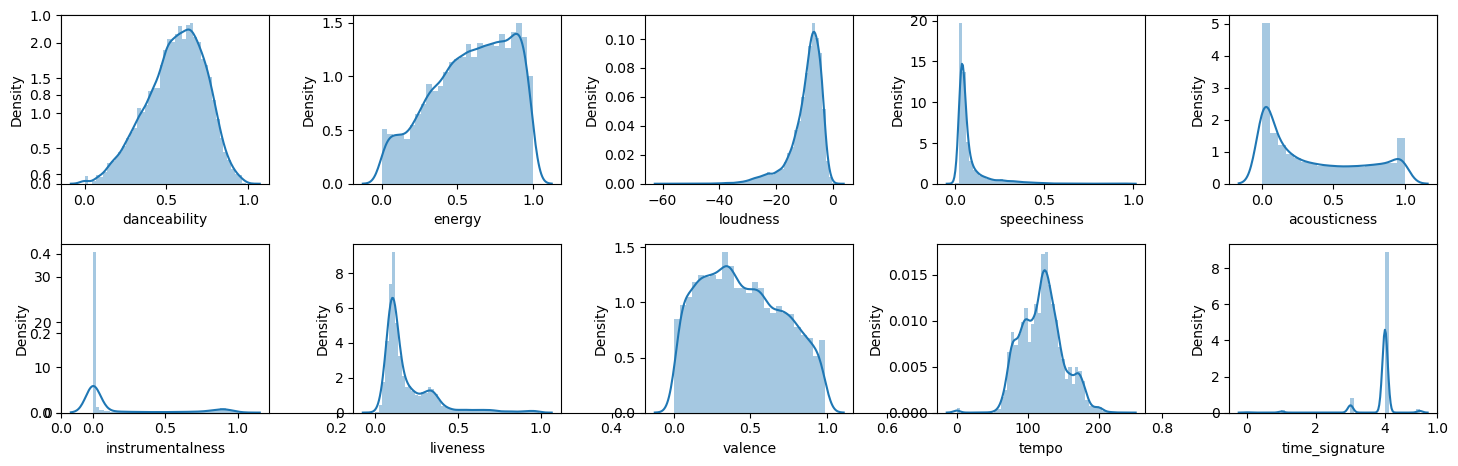

In [20]:
plt.subplots(figsize = (15, 5))
for i, col in enumerate(floats):
  plt.subplot(2, 5, i + 1)
  sns.distplot(music[col])
plt.tight_layout()
plt.show()

In [35]:


# Load the dataset
data = pd.read_csv('tracks_features.csv')  

# Drop rows with NaN values in the 'name' column
data = data.dropna(subset=['name'])

# Assuming the dataset has a 'description' or 'lyrics' column for recommendations
# Replace 'description' with the actual column name you want to use
count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(data['name'])

# Compute the cosine similarity matrix
cosine_sim = cosine_similarity(count_matrix, count_matrix)





MemoryError: Unable to allocate 431. GiB for an array with shape (57852480053,) and data type int64

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Initialize the model with the Euclidean distance metric
nbrs = NearestNeighbors(n_neighbors=5, algorithm='auto', metric='euclidean').fit(reduced_matrix)

# Find the k-nearest neighbors for each item
distances, indices = nbrs.kneighbors(reduced_matrix)

In [36]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

# Reduce dimensionality with TruncatedSVD
svd = TruncatedSVD(n_components=100)
reduced_matrix = svd.fit_transform(count_matrix)

# Compute cosine similarity on the reduced matrix
cosine_sim = cosine_similarity(reduced_matrix, reduced_matrix)





MemoryError: Unable to allocate 10.5 TiB for an array with shape (1204022, 1204022) and data type float64

In [22]:
# Function to get recommendations based on the cosine similarity score
def get_recommendations(title, cosine_sim=cosine_sim):
    # Get the index of the item that matches the title
    idx = data[data['name'] == title].index[0]  # Replace 'title' with the actual title column name

    # Get the pairwise similarity scores of all items with that item
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the items based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the 10 most similar items
    sim_scores = sim_scores[1:11]  # Exclude the first item (itself)

    # Get the indices of the most similar items
    item_indices = [i[0] for i in sim_scores]

    # Return the top 10 most similar items
    return data.iloc[item_indices]

In [ ]:
# Example usage
recommendations = get_recommendations('Calm Like a Bomb')  # Replace with an actual song title
print(recommendations)